# De Novo Lead-Binding Protein Design — Lead Sensing Project

```
RFD3  →  ProteinMPNN  →  RF3
```

Design *de novo* protein scaffolds that coordinate Pb²⁺ through a Cys3 triad motif
extracted from **PbrR691** (PDB: 5GPE, *Cupriavidus metallidurans* CH34), independent
of DNA binding or protein dimerization.

**Why PbrR691?**  
PbrR691 exhibits **>1000-fold selectivity for Pb²⁺** over competing divalent metal ions
(Chen et al., 2005). This selectivity arises from a unique **hemidirected Pb-S3
coordination geometry** at the homodimer interface, where three conserved cysteine
residues (Cys78, Cys113, Cys122 in 5GPE) form a constrained coordination environment
that Pb²⁺ fits perfectly but other metals cannot (Huang et al., 2016). PbrR691 is the
only Pb-responsive metalloregulator with an experimentally resolved Pb²⁺-bound crystal
structure, making it the ideal starting point for de novo design.

**The design problem:**  
The native PbrR691 signal is generated through Pb²⁺-dependent distortion of promoter DNA —
a complex mechanism requiring homodimerization and a DNA reporter system. We bypass this
by embedding the Pb-Cys3 motif in a *de novo* scaffold that coordinates Pb²⁺ directly,
without DNA. Previous work shows PbrR-derived motifs remain functional outside their
native context (Chen 2005, Wang 2024, Wei 2022), but the minimal structural requirements
for preserving selectivity are unknown. This design campaign tests whether the rigid
hemidirected geometry can be maintained in a completely new protein fold.

**Applications:**
- **Water/wastewater remediation** — surface-immobilized scaffold (via SpyTag+SpyCatcher)
  for selective Pb²⁺ capture from contaminated water.
- **Extracorporeal dialysis** — longer-term direction: an affinity column for circulating
  Pb²⁺ removal in acute/severe lead poisoning cases where chelation therapy is contraindicated
  (renal impairment, nephrotoxicity risk). Unlike chelators, a protein-based column avoids
  systemic metal redistribution and off-target depletion of essential metals (Zn²⁺, Cu²⁺, Fe³⁺).

**Pipeline overview:**
1. **RFD3** — generate scaffold backbones (80–140 aa) steered toward the Pb-Cys3 hotspots
   of 5GPE chains C and D, with Cys sidechain geometry frozen.
2. **ProteinMPNN** — design amino-acid sequences onto each backbone (scaffold chain A only;
   motif Cys geometry preserved).
3. **SpyTag append** — concatenate `GSGSGSAHIVMVDAYKPTK` to each MPNN sequence for
   membrane anchoring.
4. **RF3** — fold and score each construct (scaffold + SpyTag + motif context + Pb²⁺)
   to estimate interface confidence.

Everything runs on the GPU cluster via the **`c27666`** LSF queue.

---
**Motif details** (extracted by `scripts/1a_extract_motif_by_radius_literature_score.py`):
- Source structure: `data/raw/5gpe.cif` — PbrR691 (PDB: 5GPE), 8-chain homodimer
- Selected Pb site: PB_1 (`geometry_call = likely_hemidirected_pb_s3`)
- Pb-Cys3 triad (Pb-S distances from EXAFS/crystal; target 2.67 ± 0.15 Å):
  - **C78** (chain C) — Pb-S = 2.60 Å (one Cys from the 'C' protomer)
  - **D113** (chain D) — Pb-S = 2.67 Å (first Cys from the 'D' protomer)
  - **D122** (chain D) — Pb-S = 2.73 Å (second Cys from the 'D' protomer)
- Context fed to RFD3: C72–84 (13 res) and D107–128 (22 res) — 6-residue window each side

## How to run this notebook

**Read `README.md` first** for full setup. In short:

1. This notebook lives in `design/` inside your project clone.
   Run it from there — `REPO_ROOT` is auto-detected as the notebook's directory.
2. Register the shared conda env as a Jupyter kernel once (see README), then select it.
3. Run cells top to bottom. GPU stages **do not run in the notebook** — each writes an
   LSF submit script and prints a `bsub < ...` command. Run that in a terminal, wait
   for the job to finish (`bstat`), then continue with the next cell.

**Stage order:**  
RFD3 (submit → wait) → process metrics → filter → MPNN (submit → wait) → check FASTAs
→ RF3 (build JSONs → submit → wait) → score → collect best binders → [optional] tandem repeats.

**Queue notes (`c27666`):** shared on a few GPUs (~20 GB MIG slices). Keep design counts
small (defaults are tiny). Max wall time 12 h; the queue default is 15 min —
every submit script sets `-W` explicitly. Monitor with `bstat`; kill with `bkill <jobid>`.

## Setup: imports, repo paths, working directories

In [25]:
# --- Core ---
import os, sys, re, glob, json, math, shutil, csv
from pathlib import Path
from copy import deepcopy

# --- Data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Locate the repo root (the design/ folder containing this notebook) ---
REPO_ROOT = Path.cwd()
if not ((REPO_ROOT / "inputs").is_dir() and (REPO_ROOT / "lib").is_dir()):
    raise RuntimeError(
        f"cwd={REPO_ROOT} is not the repo root (no inputs/ and lib/).\n"
        "Set it manually: REPO_ROOT = Path('/dtu/blackhole/09/214281/lead_sensoring/design')"
    )

# --- Lead-sensing project inputs (pre-computed by 00_motif_scan.sh) ---
LEAD_INPUTS = REPO_ROOT / "lead_inputs"
if not LEAD_INPUTS.is_dir():
    raise RuntimeError(
        f"lead_inputs/ not found under {REPO_ROOT}. "
        "Run 00_motif_scan.sh first to generate the motif inputs."
    )

# --- Key input files ---
# Full 5GPE CIF structure (PbrR691 homodimer with Pb2+; RFD3 input)
STRUCTURE_CIF = (REPO_ROOT.parent / "data" / "raw" / "5gpe.cif").resolve()
# Reduced context PDB: chains C (res 72-84) + D (res 107-128) + Pb2+ atom only
# This is the trimmed target used for RF3 folding (generated by 1c_export_rfd3_context_structure.py)
CONTEXT_PDB = (LEAD_INPUTS / "rfd3_context_fixed_segments_plus_pb.pdb").resolve()

for p in [STRUCTURE_CIF, CONTEXT_PDB]:
    if not p.exists():
        print(f"[WARNING] Not found: {p}")

# --- Helper modules (note: nested lib/lib/ in this repo clone) ---
sys.path.insert(0, str(REPO_ROOT / "lib" / "lib"))
import jupyter_utils
from rf3_metrics import gather_rf3_metrics

print("Repo root  :", REPO_ROOT)
print("Lead inputs:", LEAD_INPUTS)
print("5GPE CIF   :", STRUCTURE_CIF)
print("Context PDB:", CONTEXT_PDB)
print("User       :", os.environ.get("USER", "?"))

Repo root  : /dtu/blackhole/09/214281/lead_sensoring/design
Lead inputs: /dtu/blackhole/09/214281/lead_sensoring/design/lead_inputs
5GPE CIF   : /dtu/blackhole/09/214281/lead_sensoring/data/raw/5gpe.cif
Context PDB: /dtu/blackhole/09/214281/lead_sensoring/design/lead_inputs/rfd3_context_fixed_segments_plus_pb.pdb
User       : s243548


In [26]:
# All run outputs go under work/<experiment>/ inside the design/ folder (git-ignored).
experiment = "exp_01"          # bump for each new design round
WORK = REPO_ROOT / "work" / experiment

_subdirs = ["cmds", "submit", "logs", "configs", "scores",
            "diffusion_out", "mpnn_out", "rf3_out", "best_binders"]
for d in _subdirs:
    (WORK / d).mkdir(parents=True, exist_ok=True)

cmds_dir          = str(WORK / "cmds")
submit_dir        = str(WORK / "submit")
logs_dir          = str(WORK / "logs")
configs_dir       = str(WORK / "configs")
scores_dir        = str(WORK / "scores")
diffusion_out_dir = str(WORK / "diffusion_out")
mpnn_out_dir      = str(WORK / "mpnn_out")
rf3_out_dir       = str(WORK / "rf3_out")
best_binders_dir  = str(WORK / "best_binders")

# --- SpyTag for C-terminal membrane anchoring (via SpyCatcher) ---
# SpyCatcher-coated membrane + this tag = covalent attachment via spontaneous isopeptide bond.
# The GSGSGS linker decouples the rigid Pb-binding scaffold from the tag,
# keeping the tag surface-exposed for SpyCatcher conjugation.
# This sequence is appended AFTER MPNN designs the scaffold (before RF3 validation).
SPYTAG_LINKER = "GSGSGS"          # 6 aa GS-repeat flexible linker
SPYTAG_SEQ    = "AHIVMVDAYKPTK"   # 13 aa SpyTag (Baker lab, Zakeri et al. 2012)
SPYTAG        = SPYTAG_LINKER + SPYTAG_SEQ   # 19 aa total C-terminal extension

pd.set_option("display.max_columns", None)
print("Working dir:", WORK)
print("SpyTag     :", SPYTAG, f"({len(SPYTAG)} aa)")

Working dir: /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01
SpyTag     : GSGSGSAHIVMVDAYKPTK (19 aa)


## Scientific background and design rationale

### Why the Cys geometry must be preserved exactly

The extraordinary Pb²⁺ selectivity of PbrR691 arises from a **hemidirected coordination
geometry**: the three Cys SG atoms (from C78, D113, D122) are positioned on one side of
the metal, with the opposite side sterically open. This arrangement accommodates Pb²⁺'s
unique 6s² lone pair (which dictates hemidirected geometry) but is incompatible with
Zn²⁺, Cd²⁺, or other competing metals that prefer symmetric (holodirected) coordination.

Pb-S distances of ~2.67 Å (EXAFS) and the specific S-Pb-S angles are critical — even
small deviations reduce selectivity. This is why we set `redesign_motif_sidechains: false`
in RFD3: the crystallographic Cys coordinates are frozen, preserving the exact geometry
that evolution optimized.

### Design strategy: binder-style scaffolding

In native PbrR691, the Pb-Cys3 site sits at the interface of a homodimer (chain C + chain D).
Our approach treats those dimer interface segments (C72–84 and D107–128) as a **pseudo-target**
and uses RFD3 in binder-design mode to generate a *de novo* scaffold that wraps around them:

```
RFD3 output (3 chains):
  Chain A  — new scaffold (80–140 aa, the designed protein)
  Chain C  — frozen segment from 5GPE (res 72–84, contains Cys78)
  Chain D  — frozen segment from 5GPE (res 107–128, contains Cys113, Cys122)
  + Pb²⁺   — held in place by the frozen Cys triad
```

Chain A is the actual product — a single-chain protein that contacts all three Cys
residues and thereby holds the Pb²⁺ coordination site in the correct geometry without
needing a partner protomer or DNA.

### Multiple Pb-binding sites and sensor sensitivity

Avidity matters for low-concentration detection and for affinity columns. A tandem repeat
of the scaffold (two copies linked by GSGSGSG) provides two independent Pb²⁺ sites per
chain, doubling capture capacity without requiring co-expression of multiple chains.
The SpyTag at the C-terminus anchors the tandem protein on the membrane in a defined
orientation. See the optional tandem-repeat cell at the end of this notebook.

### Key literature

| Ref | Finding relevant to this project |
|-----|-----------------------------------|
| Chen et al., *Angew. Chem.* 2005 | PbrR691 shows >1000-fold selectivity; first fluorescent Pb²⁺ reporter via DNA distortion |
| Huang et al., *Inorg. Chem.* 2016 | Crystal structure of 5GPE; hemidirected Pb-S3 geometry at dimer interface |
| Wang et al., *Anal. Chim. Acta* 2024 | PbrR-derived peptide fused to sfGFP detects Pb²⁺ in serum — motif works outside native context |
| Wei et al., *Polym. Chem.* 2022 | PbrR-derived peptide in PNIPAM hydrogel for reversible Pb²⁺ capture — rigidity is key |
| Zakeri et al., *PNAS* 2012 | SpyTag/SpyCatcher isopeptide bond system for irreversible surface attachment |

## 1. RFD3 — generate scaffold backbones embedding the Pb-Cys3 motif

RFD3 diffuses a new protein backbone from noise in **motif-scaffolding mode**: the
Pb-Cys3 residues from PbrR691 (5GPE) are embedded *within* a single new chain, flanked
by freely diffused regions. The result is a single expressed protein chain that directly
coordinates Pb²⁺ via its own Cys residues — no partner chains required.

**`contig`** — single continuous chain, no chain breaks:
- `10-50` — free N-terminal scaffold region (new backbone, diffused by RFD3)
- `C72-84` — fixed 13-residue segment from chain C of 5GPE (contains **Cys78**, Pb-S = 2.60 Å)
- `5-20` — free linker region between the two motif segments
- `D107-128` — fixed 22-residue segment from chain D of 5GPE (contains **Cys113** and **Cys122**)
- `10-50` — free C-terminal scaffold region (connects to the SpyTag)

All segments are in **one chain A** with no `/0` chain breaks. Cys78, Cys113, and Cys122
are embedded directly in chain A, so the expressed protein carries the complete Pb-Cys3
triad. This is motif-scaffolding, not binder design.

**`redesign_motif_sidechains: false`** — the crystallographic Cys sidechain coordinates
from 5GPE are frozen throughout diffusion. This is essential: the hemidirected Pb-S3
geometry that gives PbrR691 its >1000-fold selectivity depends on exact Pb-S distances
(~2.67 Å) and S-Pb-S angles. Even small distortions to the Cys positions would compromise
selectivity.

**`is_non_loopy: true`** — biases RFD3 toward helical secondary structure. More ordered
scaffolds produce better MPNN sequences and higher RF3 pLDDT.

**`inference_sampler.step_scale=3` and `gamma_0=0.2`** — lower-temperature diffusion;
produces more structured, designable backbones.

---
**Multi-site strategy:** Each designed chain A contains **one complete Pb-Cys3 motif**.
For two Pb²⁺ sites, duplicate the best MPNN sequence with a GSGSGSG linker (see the
optional tandem-repeat cell at the end). Since the motif is now fully inside chain A,
each copy in the tandem provides one independent coordination site.

### Build the RFD3 input JSON

This cell generates the RFD3 input JSON. The resulting file is equivalent to
`lead_inputs/rfd3_input_radius_4p0.json` pre-computed by the motif scan pipeline,
but with the correct absolute path for this clone's 5GPE CIF.

In [27]:
design_name = "5gpe_pb_motif_r4"

# RFD3 input: pre-trimmed context PDB with only the motif segments and Pb2+.
# We use this instead of the full 5gpe.cif because inference_load_() builds the
# biological assembly from CIF files, which remaps chains A-H → A, B, I, J —
# eliminating chains C and D that the contig references.
# rfd3_input_context.pdb has: chain C (res 72-84), chain D (res 107-128),
# chain E (Pb2+, moved off chain C to avoid chain-overlap error).
input_pdb = str(LEAD_INPUTS / "rfd3_input_context.pdb")

# ── Contig (motif-scaffolding mode — single continuous chain) ───────────────────
# 10-50    : free N-terminal region (new diffused backbone)
# C72-84   : fixed 13-residue segment from chain C (contains Cys78; Pb-S = 2.60 Å)
# 5-20     : free linker between the two motif segments
# D107-128 : fixed 22-residue segment from chain D (contains Cys113 and Cys122)
# 10-50    : free C-terminal region (connects to SpyTag)
#
# No chain breaks (/0) — all segments are in one continuous chain A.
# Cys78, Cys113, Cys122 are EMBEDDED in chain A, so the expressed protein
# coordinates Pb2+ directly without requiring any partner chains.
contig = "10-50,C72-84,5-20,D107-128,10-50"

# Total design length = (10-50) + 13 + (5-20) + 22 + (10-50) = 60-155
length = "60-155"

# Critical: freeze Cys sidechain coordinates to preserve the hemidirected Pb-S3
# coordination geometry that underlies PbrR691's >1000-fold Pb2+ selectivity.
redesign_motif_sidechains = False

# Motif-scaffolding mode: hotspots and origin strategy are not used — RFD3 diffuses
# free regions directly around the fixed Cys segments embedded in chain A.
select_hotspots    = None
infer_ori_strategy = None
is_non_loopy       = True   # bias toward helices; fewer loops → better designability

rfd3_json = str(Path(configs_dir) / "rfd3_input.json")

payload_body = {
    "dialect": 2,
    "input": input_pdb,
    "contig": contig,
    "length": length,
    "redesign_motif_sidechains": redesign_motif_sidechains,
    "is_non_loopy": is_non_loopy,
}
# Only include optional keys when set (RFD3 rejects null values for these params)
if select_hotspots:
    payload_body["select_hotspots"] = select_hotspots
if infer_ori_strategy:
    payload_body["infer_ori_strategy"] = infer_ori_strategy

payload = {design_name: payload_body}
with open(rfd3_json, "w") as f:
    json.dump(payload, f, indent=2)

print("Wrote RFD3 input ->", rfd3_json)
print("Input PDB  :", input_pdb)
print("Design name:", design_name)
print("Contig     :", contig)
print("Length     :", length)
print()
print("Pre-computed reference contig (binder-mode — for reference only):")
ref = LEAD_INPUTS / "rfd3_input_radius_4p0.json"
if ref.exists():
    with open(ref) as f:
        ref_data = json.load(f)
    ref_contig = list(ref_data.values())[0]["contig"]
    print(f"  Reference contig: {ref_contig}")
    print(f"  (Motif-scaffolding contig differs intentionally — see cell-5 rationale)")

Wrote RFD3 input -> /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/configs/rfd3_input.json
Input PDB  : /dtu/blackhole/09/214281/lead_sensoring/design/lead_inputs/rfd3_input_context.pdb
Design name: 5gpe_pb_motif_r4
Contig     : 10-50,C72-84,5-20,D107-128,10-50
Length     : 60-155

Pre-computed reference contig (binder-mode — for reference only):
  Reference contig: 80-140,/0,C72-84,/0,D107-128
  (Motif-scaffolding contig differs intentionally — see cell-5 rationale)


### Write the RFD3 submit script

Default: `diffusion_batch_size=1 × n_batches=4` → **4 backbones** total — deliberately
small to respect the shared queue. For a production run, increase `n_batches` to 50–200
and extend `-W` accordingly. **Always check `bqueues c27666` before scaling up.**

Key RFD3 hyperparameters:
- `inference_sampler.step_scale=3` and `gamma_0=0.2` — lower-temperature sampling;
  produces more structured backbones that are easier to sequence-design downstream.
  These settings are specifically recommended for protein–protein interface design.

In [28]:
queue        = "c27666"
job_name     = "rfd3_pb"
cores        = 4
gpu_spec     = "num=1:mode=exclusive_process"
time_limit   = "1:00"
mem          = "10GB"

# Model weights (local blackhole copy; same checkpoint as /dtu/projects/dbl/foundry/ckpt/)
CKPT_PATH = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/rfd3_latest.ckpt"

diffusion_batch_size = 1    # backbones per GPU batch
n_batches            = 4    # total backbones = diffusion_batch_size * n_batches

script_path = os.path.join(submit_dir, "rfd3.sh")

script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J.out
#BSUB -e {logs_dir}/%J.err

mkdir -p {logs_dir} {diffusion_out_dir}
module load cuda/12.4
source /dtu/blackhole/00/c27666/miniforge3/etc/profile.d/conda.sh
conda activate /dtu/blackhole/00/c27666/miniforge3/envs/protein-design

# Workarounds for MIG GPU slices on c27666 A100s
export DISABLE_CUEQUIVARIANCE=true           # skip cuEquivariance (crashes on MIG via pynvml)
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True  # reduce fragmentation on ~20GB slice

rfd3 design \\
    out_dir="{diffusion_out_dir}" \\
    inputs="{rfd3_json}" \\
    ckpt_path="{CKPT_PATH}" \\
    diffusion_batch_size={diffusion_batch_size} \\
    n_batches={n_batches} \\
    low_memory_mode=True \\
    inference_sampler.step_scale=3 \\
    inference_sampler.gamma_0=0.2

echo "Completed at $(date)"
"""

with open(script_path, "w") as f:
    f.write(script)

print("Wrote", script_path)
print(f"\nThis will generate {diffusion_batch_size * n_batches} backbone(s).")
print("\nSubmit in a terminal:")
print("  bsub < " + script_path)
print("Monitor: bstat   (job disappears when done)")
print("Logs   :", logs_dir)

Wrote /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/submit/rfd3.sh

This will generate 4 backbone(s).

Submit in a terminal:
  bsub < /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/submit/rfd3.sh
Monitor: bstat   (job disappears when done)
Logs   : /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/logs


### Process RFD3 outputs

Each backbone is written as a `.cif.gz` plus a `.json` of geometry metrics. Run the cells
below **after** the RFD3 job finishes to gather and inspect those metrics.

Key metrics to watch:
- **`helix_fraction`** — fraction of residues in helical SS; higher is better for well-packed
  stable designs (especially with `is_non_loopy=True`). Aim for > 0.6.
- **`loop_fraction`** — ideally < 0.4 for designable backbones.
- **`n_chainbreaks`** — should be **0** (single continuous chain — no chain breaks in
  motif-scaffolding mode; any value > 0 indicates an unexpected break).
- **`n_clashing.*`** — both should be 0 (any clashes indicate a failed backbone).
- **`radius_of_gyration`** — compactness proxy; very large values suggest extended/unfolded backbones.

In [29]:
json_rfd3_dir    = diffusion_out_dir
rfd3_metrics_csv = Path(scores_dir) / "rfd3_metrics_with_json_path.csv"

json_paths = sorted(glob.glob(os.path.join(json_rfd3_dir, "*.json")))
if not json_paths:
    raise SystemExit(f"No JSON files found in {json_rfd3_dir!r} — run RFD3 first.")

rows = []
all_keys = set(["json_path"])

for jp in json_paths:
    with open(jp, "r") as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    row = {"json_path": os.path.abspath(jp)}
    for k, v in metrics.items():
        if k in ("diffused_com", "fixed_com") and isinstance(v, (list, tuple)) and len(v) == 3:
            row[f"{k}_x"], row[f"{k}_y"], row[f"{k}_z"] = v
            all_keys.update({f"{k}_x", f"{k}_y", f"{k}_z"})
        else:
            row[k] = v
            all_keys.add(k)
    rows.append(row)

fieldnames = ["json_path"] + sorted(k for k in all_keys if k != "json_path")

with open(rfd3_metrics_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f"Wrote {len(rows)} rows → {rfd3_metrics_csv}")
print("Columns:", fieldnames)

Wrote 4 rows → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/scores/rfd3_metrics_with_json_path.csv
Columns: ['json_path', 'alanine_content', 'diffused_com_x', 'diffused_com_y', 'diffused_com_z', 'fixed_com_x', 'fixed_com_y', 'fixed_com_z', 'glycine_content', 'helix_fraction', 'loop_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'num_residues', 'num_ss_elements', 'radius_of_gyration', 'sheet_fraction']


In [30]:
df = pd.read_csv(rfd3_metrics_csv)
df.head(10)

,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.392523,-0.006909,0.025079,0.560469,-0.000821,-0.000655,-0.000651,0.037383,0.666667,0.333333,0.084471,0,0,1,0.666667,107,3,15.877420,0.0
1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.357143,-0.753327,-7.934482,-1.100884,-0.000821,-0.000655,-0.000651,0.047619,0.632653,0.367347,0.084471,0,0,0,0.632653,84,3,12.827856,0.0
2,/dtu/blackhole/09/214281/lead_sensoring/design...,0.322581,-5.105363,-7.456125,-1.041458,-0.000821,-0.000655,-0.000651,0.053763,0.672414,0.327586,0.084471,0,0,1,0.672414,93,3,11.794620,0.0
3,/dtu/blackhole/09/214281/lead_sensoring/design...,0.535354,1.634697,-1.871807,-0.084736,-0.000821,-0.000655,-0.000651,0.030303,0.796875,0.203125,0.084471,0,0,0,0.796875,99,3,16.500152,0.0


Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


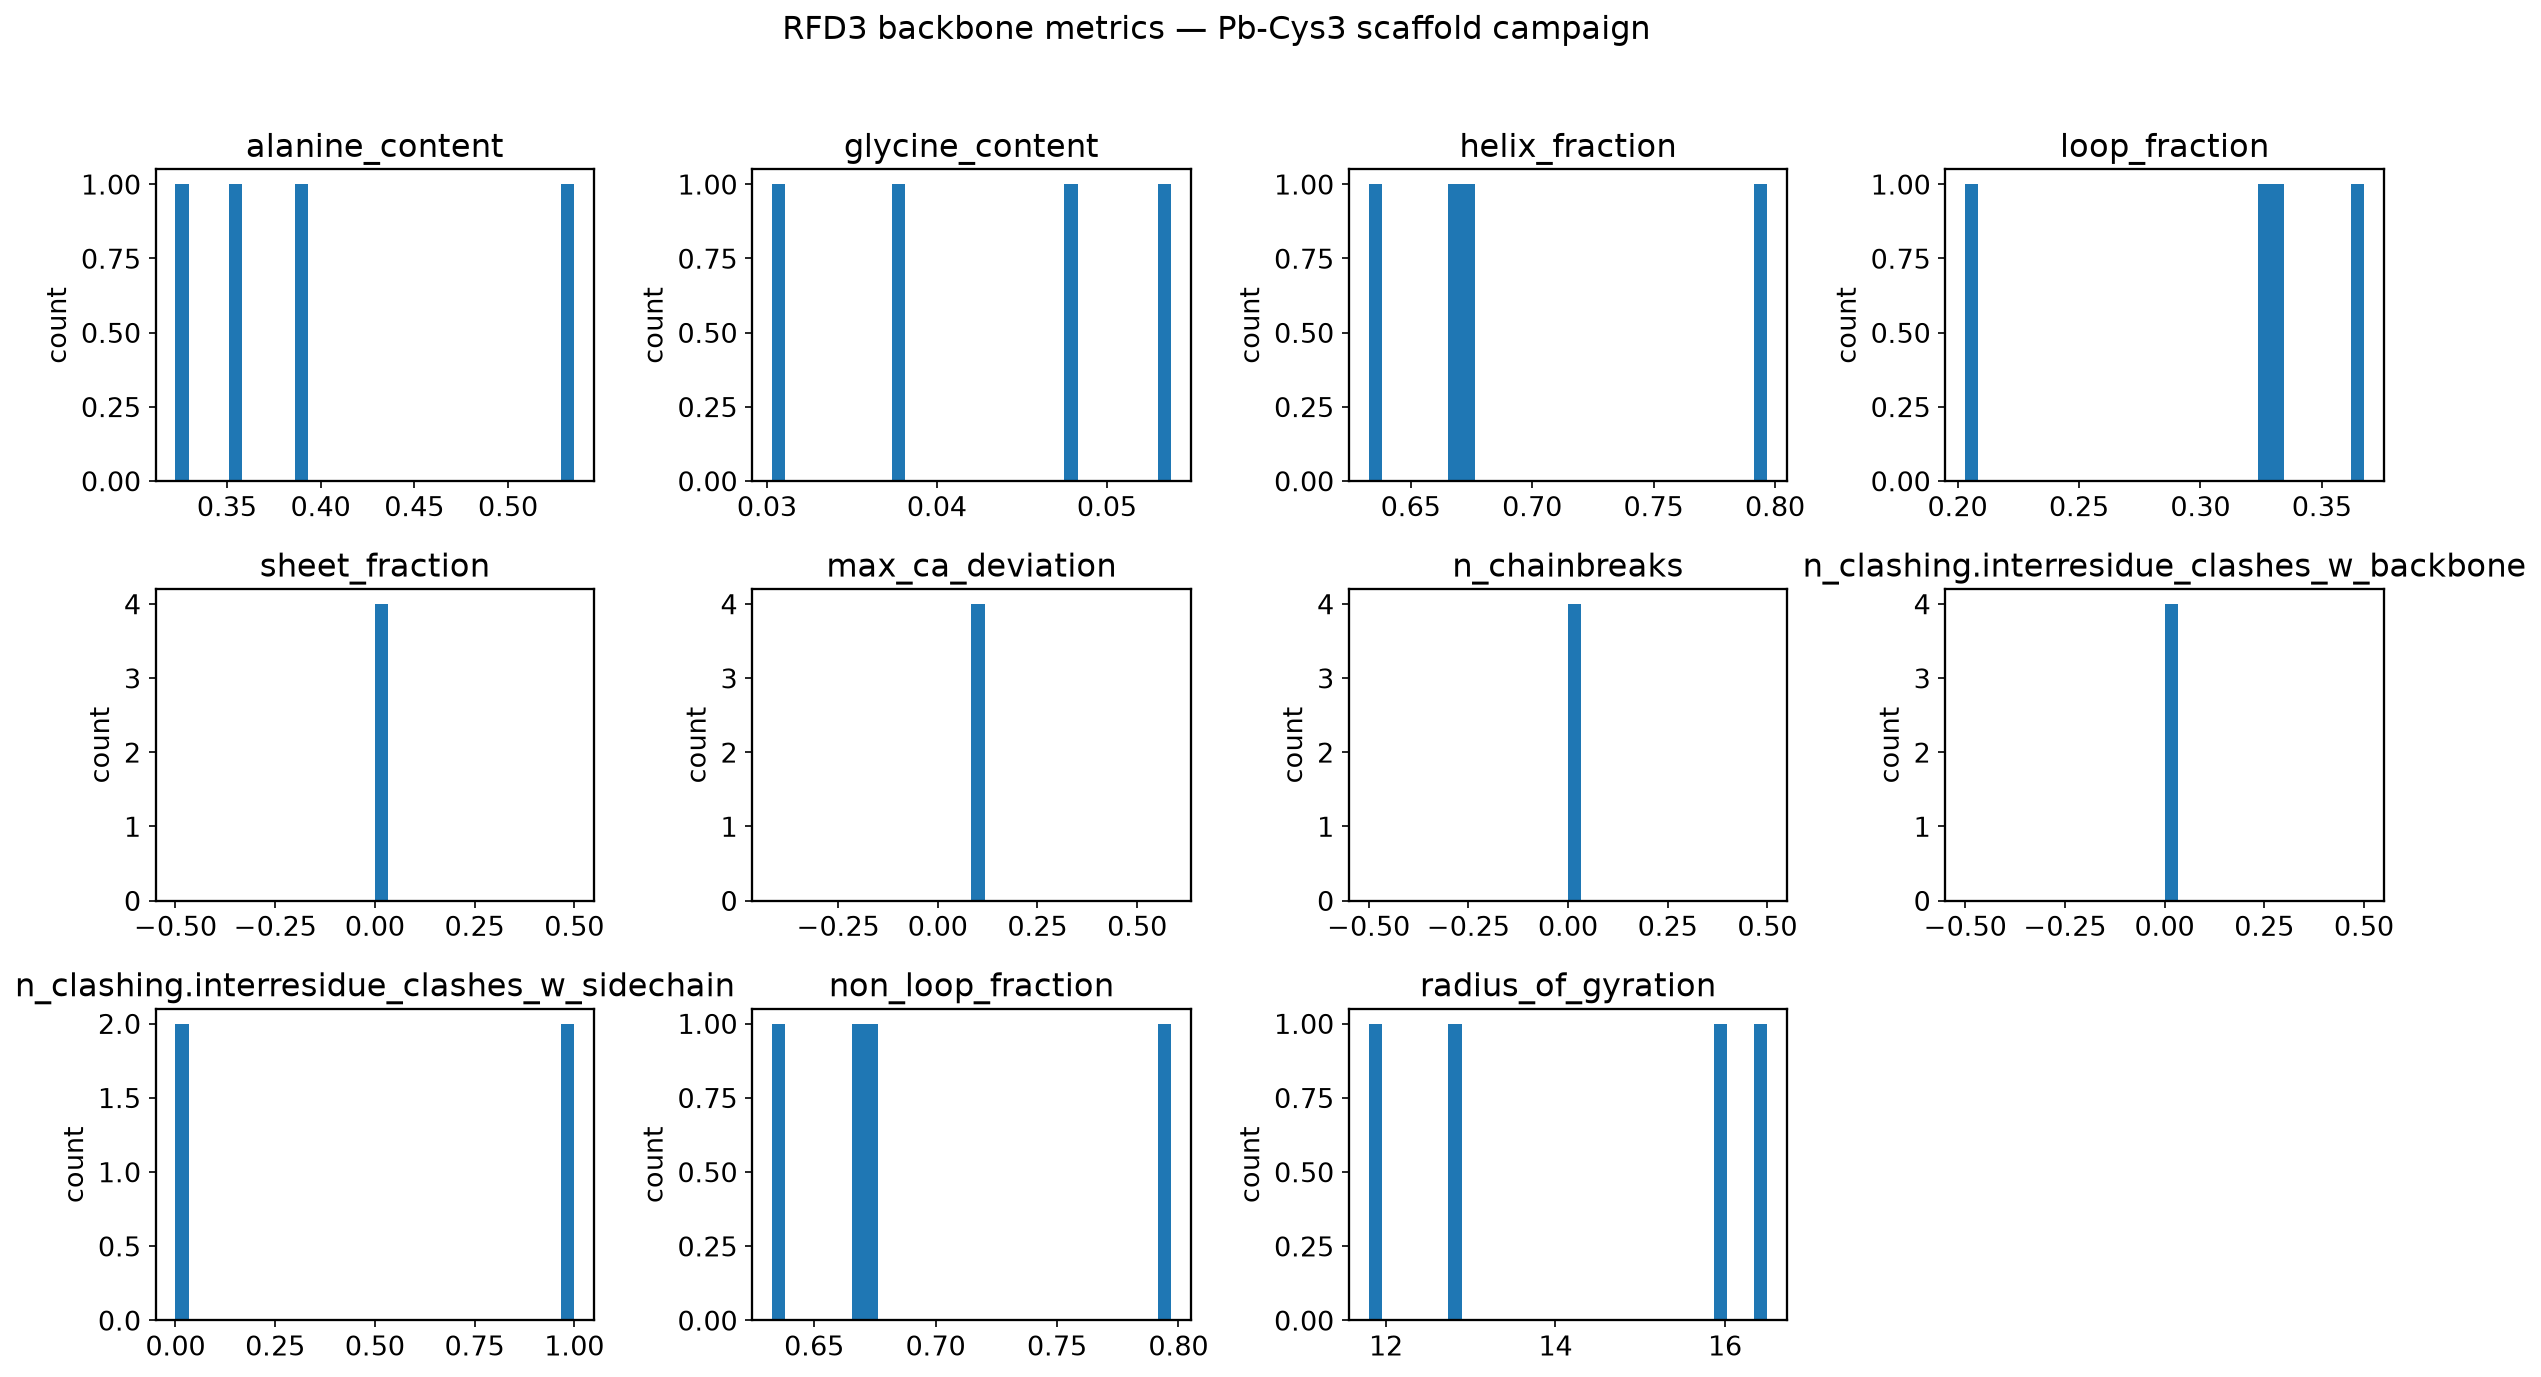

In [31]:
metrics = [
    "alanine_content",
    "glycine_content",
    "helix_fraction",
    "loop_fraction",
    "sheet_fraction",
    "max_ca_deviation",
    "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction",
    "radius_of_gyration",
]

metrics = [m for m in metrics if m in df.columns]
print("Plotting:", metrics)

n_cols = 4
n_rows = math.ceil(len(metrics) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

def plot_hist(ax, series, title):
    s = series.dropna()
    if s.empty:
        ax.set_title(f"{title} (no data)")
        ax.axis("off")
        return
    ax.hist(s, bins=30)
    ax.set_title(title)
    ax.set_ylabel("count")

for ax, col in zip(axes, metrics):
    plot_hist(ax, df[col], col)
for ax in axes[len(metrics):]:
    ax.axis("off")

plt.suptitle("RFD3 backbone metrics — Pb-Cys3 scaffold campaign", y=1.02)
plt.tight_layout()
plt.show()

### Optional: filter backbones by secondary structure content

Backbones with too much loop tend to produce less stable designs downstream.
Since we set `is_non_loopy=True`, most backbones should pass the `loop_fraction < 0.4`
threshold. Passing designs are copied to `passing_loop_nonloop/` so MPNN picks them up;
if none pass (very small batch), MPNN falls back to the full set.

Skip this section to keep **all** backbones.

In [32]:
df_filt = df[
    (df["loop_fraction"] < 0.4) &
    (df["non_loop_fraction"] > 0.6)
].copy()

print(f"Total designs  : {len(df)}")
print(f"Passing designs: {len(df_filt)}")
df_filt.head()

Total designs  : 4
Passing designs: 4


,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.392523,-0.006909,0.025079,0.560469,-0.000821,-0.000655,-0.000651,0.037383,0.666667,0.333333,0.084471,0,0,1,0.666667,107,3,15.877420,0.0
1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.357143,-0.753327,-7.934482,-1.100884,-0.000821,-0.000655,-0.000651,0.047619,0.632653,0.367347,0.084471,0,0,0,0.632653,84,3,12.827856,0.0
2,/dtu/blackhole/09/214281/lead_sensoring/design...,0.322581,-5.105363,-7.456125,-1.041458,-0.000821,-0.000655,-0.000651,0.053763,0.672414,0.327586,0.084471,0,0,1,0.672414,93,3,11.794620,0.0
3,/dtu/blackhole/09/214281/lead_sensoring/design...,0.535354,1.634697,-1.871807,-0.084736,-0.000821,-0.000655,-0.000651,0.030303,0.796875,0.203125,0.084471,0,0,0,0.796875,99,3,16.500152,0.0


In [33]:
PATH_COL = "json_path"
filter_name = "passing_loop_nonloop"

filtered_dir = Path(diffusion_out_dir) / filter_name
filtered_dir.mkdir(parents=True, exist_ok=True)

def copy_design(json_path: str, dst_dir: Path) -> int:
    """Copy one design's JSON and its matching CIF/CIF.GZ into dst_dir."""
    jp = Path(json_path)
    if not jp.exists():
        return 0
    copied = 0
    dst_json = dst_dir / jp.name
    if not dst_json.exists():
        shutil.copy2(jp, dst_json)
        copied += 1
    stem = jp.stem
    for cif in (jp.with_name(stem + ".cif"), jp.with_name(stem + ".cif.gz")):
        if cif.exists():
            dst_cif = dst_dir / cif.name
            if not dst_cif.exists():
                shutil.copy2(cif, dst_cif)
                copied += 1
    return copied

total_copied = missing = 0
unique_paths = df_filt[PATH_COL].dropna().unique()
for pth in unique_paths:
    if not isinstance(pth, str) or not os.path.exists(pth):
        print(f"[MISSING] {pth}")
        missing += 1
        continue
    total_copied += copy_design(pth, filtered_dir)

print(f"Passing designs: {len(unique_paths)}")
print(f"Copied files   : {total_copied}")
print(f"Output folder  : {filtered_dir}")

Passing designs: 4
Copied files   : 0
Output folder  : /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/diffusion_out/passing_loop_nonloop


## 2. ProteinMPNN — design sequences

ProteinMPNN writes amino-acid sequences onto each RFD3 backbone. We redesign the whole
scaffold chain (`A`) freely; the motif chains (C and D from 5GPE) are fixed — ProteinMPNN
sees them as context but does not redesign them. This preserves the Cys3 triad exactly
as crystallographically observed.

After MPNN, we append the SpyTag (`GSGSGSAHIVMVDAYKPTK`) to every designed sequence
in the RF3 input-building step below.

This builds one command per backbone and submits them as a single LSF **job array**.

In [34]:
seed              = 42
batch_size        = 2     # sequences per backbone per batch
number_of_batches = 2     # total sequences per backbone = batch_size * number_of_batches

# ProteinMPNN weights (local blackhole copy)
ckpt = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/proteinmpnn_v_48_020.pt"

cmds = f"{cmds_dir}/mpnn.cmds"
filtered = sorted(glob.glob(f"{diffusion_out_dir}/passing_loop_nonloop/*.cif.gz"))
structures = filtered if filtered else sorted(glob.glob(f"{diffusion_out_dir}/*.cif.gz"))
print(f"Using {len(structures)} backbone(s) "
      + ("(loop-filtered)" if filtered else "(all backbones — no filter applied)"))
if not structures:
    raise SystemExit(f"No backbones (*.cif.gz) in {diffusion_out_dir} — run RFD3 first.")

# Scan each CIF for CYS CA atoms in chain A — those are the Pb-binding residues
# embedded by RFD3 with redesign_motif_sidechains=False. Fix them so MPNN cannot
# change them (Pb coordination would be lost).
# Note: --fixed_residues and --designed_chains are mutually exclusive in this CLI.
# --fixed_residues expects comma-separated IDs: "A27,A51,A60" (no spaces).
import gzip as _gz_mpnn

def _cys_positions_chain_a(cif_gz_path):
    """Return sorted 1-indexed positions of CYS CA atoms in chain A of an RFD3 CIF."""
    opener = _gz_mpnn.open if str(cif_gz_path).endswith('.gz') else open
    with opener(cif_gz_path, 'rt') as fh:
        lines = fh.readlines()
    cols, in_atom_loop, col_idx = {}, False, 0
    positions, seen = [], set()
    for raw in lines:
        s = raw.strip()
        if s == 'loop_':
            in_atom_loop, col_idx, cols = False, 0, {}
            continue
        if s.startswith('_atom_site.'):
            in_atom_loop = True
            cols[s.split('.', 1)[1]] = col_idx
            col_idx += 1
            continue
        if in_atom_loop and cols and s and not s.startswith('_') and not s.startswith('#'):
            parts = s.split()
            try:
                chain  = parts[cols['label_asym_id']]
                comp   = parts[cols['label_comp_id']]
                seq_id = int(parts[cols['label_seq_id']])
                atom   = parts[cols['label_atom_id']]
            except (KeyError, IndexError, ValueError):
                continue
            if chain == 'A' and comp == 'CYS' and atom == 'CA' and seq_id not in seen:
                positions.append(seq_id)
                seen.add(seq_id)
        elif in_atom_loop and cols and (s.startswith('_') or s.startswith('loop_') or s.startswith('#')):
            break
    return sorted(positions)

with open(cmds, "w") as f:
    for structure in structures:
        bn = os.path.basename(structure).replace(".cif.gz", "")
        this_out = f"{mpnn_out_dir}/{bn}"
        os.makedirs(this_out, exist_ok=True)

        # Comma-separated residue IDs: "A27,A51,A60" — required format for this CLI.
        # Mutually exclusive with --designed_chains; do not combine them.
        cys_pos = _cys_positions_chain_a(structure)
        if cys_pos:
            fixed_arg = f'--fixed_residues "{",".join(f"A{p}" for p in cys_pos)}"'
        else:
            print(f"[WARNING] {bn}: no CYS in chain A — motif positions unprotected")
            fixed_arg = '--designed_chains "A"'

        cmd = (f"mpnn --seed {seed} --structure_path \"{structure}\" "
               f"--out_directory \"{this_out}\" --batch_size {batch_size} "
               f"--number_of_batches {number_of_batches} --model_type protein_mpnn "
               f"--checkpoint_path \"{ckpt}\" --is_legacy_weights True "
               f"{fixed_arg}")
        f.write(cmd.strip() + "\n")

n_tasks = sum(1 for _ in open(cmds))
sub_script = jupyter_utils.make_sub_script(
    cmds, n_task=n_tasks, group_size=10, mem="10G", queue="c27666",
    job_name="mpnn_pb", cores=4, time_limit="2:00",
    env="/dtu/blackhole/00/c27666/miniforge3/envs/protein-design",
)
print(f"\n{n_tasks} MPNN command(s) written to: {cmds}")
print(f"Each backbone gets {batch_size * number_of_batches} sequence(s).")
print("Submit:\n  bsub < " + sub_script)

Using 4 backbone(s) (loop-filtered)
Submit script written: /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/cmds/mpnn.sh

4 MPNN command(s) written to: /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/cmds/mpnn.cmds
Each backbone gets 4 sequence(s).
Submit:
  bsub < /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/cmds/mpnn.sh


### SpyTag strategy and multiple-site design

**SpyTag** (`GSGSGSAHIVMVDAYKPTK`, 19 aa):
- The 6-residue GSGSGS linker provides conformational flexibility so the Pb-binding
  scaffold and the membrane surface can move independently — critical because the
  rigid Pb-coordination geometry must not be distorted by surface attachment.
- The 13-residue SpyTag forms a **spontaneous isopeptide bond** with SpyCatcher
  (Lys→Asp side chains, no catalyst required, essentially irreversible).
- For sensing: SpyCatcher-coated magnetic beads or membranes capture the protein
  in a defined orientation, pointing the Pb-binding site toward the solution.
- For the dialysis column application: SpyCatcher-functionalized resin immobilizes
  the protein in a packed column for flow-through Pb²⁺ capture from blood/plasma.

The SpyTag is appended to each MPNN sequence **in the RF3 input-building step** below,
so RF3 folds the full construct and we can check that the tag region is surface-accessible.
In the RF3 output, low pLDDT in the last ~19 residues of chain A is **acceptable** —
an unstructured, flexible tag is exactly what allows SpyCatcher binding.

**Multiple Pb-binding sites (tandem repeat approach):**  
Each monomer has one Pb²⁺ binding site. To double the capture capacity:
```
[scaffold_1] — GSGSGSG — [scaffold_2] — GSGSGSAHIVMVDAYKPTK
```
This tandem protein has **two independent Pb-Cys3 sites** plus the SpyTag, all in
one single chain (~200–300 aa total). See the optional cell at the end of this notebook.

Run the cell below **after MPNN finishes** to verify that FASTA files are present.

In [35]:
# Inspect MPNN output FASTAs (run after MPNN job completes)
fa_files = sorted(glob.glob(os.path.join(mpnn_out_dir, "**", "*.fa"), recursive=True))
print(f"Found {len(fa_files)} FASTA file(s) under {mpnn_out_dir}")
for fa in fa_files[:5]:
    print(" ", fa)
if len(fa_files) > 5:
    print(f"  ... and {len(fa_files)-5} more")
if not fa_files:
    print("No FASTAs found — run MPNN first, then re-run this cell.")

Found 4 FASTA file(s) under /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/mpnn_out
  /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/mpnn_out/rfd3_input_5gpe_pb_motif_r4_0_model_0/rfd3_input_5gpe_pb_motif_r4_0_model_0.cif.fa
  /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/mpnn_out/rfd3_input_5gpe_pb_motif_r4_1_model_0/rfd3_input_5gpe_pb_motif_r4_1_model_0.cif.fa
  /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/mpnn_out/rfd3_input_5gpe_pb_motif_r4_2_model_0/rfd3_input_5gpe_pb_motif_r4_2_model_0.cif.fa
  /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/mpnn_out/rfd3_input_5gpe_pb_motif_r4_3_model_0/rfd3_input_5gpe_pb_motif_r4_3_model_0.cif.fa


## 3. RF3 — fold and score each construct

RF3 folds the complete chain A construct (MPNN sequence + SpyTag) as a **single chain**.
In motif-scaffolding mode, chain A already contains Cys78, Cys113, and Cys122 from 5GPE —
there is no separate context chain. RF3 evaluates fold quality of chain A alone.

Metrics to assess:

| Metric | Meaning | Target |
|--------|---------|--------|
| `best_binder_plddt` | Per-residue pLDDT confidence of chain A (0–1) | > 0.8 |

**SpyTag pLDDT** — the last ~19 residues of chain A (GSGSGSAHIVMVDAYKPTK). Low pLDDT
(< 0.7) at the C-terminus is **acceptable and expected**: a flexible, disordered tag is
what allows SpyCatcher binding.

After RF3, inspect top candidates in PyMOL or ChimeraX to verify:
1. The three Cys residues are spatially close (~5 Å apart) and geometrically consistent
   with hemidirected Pb-S3 coordination.
2. The scaffold is compact with no large voids near the Cys triad.
3. The SpyTag (last 19 residues) is surface-exposed.

**Chain ID in RF3 output:**
```
A_1 — de novo scaffold + SpyTag (the full expressed protein)
```

### Write RF3 template and build RF3 input JSONs

First we write a project-specific RF3 template JSON that specifies:
- **Chain A component** — binder sequence placeholder (filled in per MPNN design + SpyTag)
- **Context path** — `rfd3_context_fixed_segments_plus_pb.pdb` (chains C, D + Pb²⁺ atom)
- **`template_selection`** — tell RF3 to use chains C and D as structural templates

Then one RF3 input JSON is instantiated per MPNN sequence (with SpyTag appended).

In [36]:
# Write the RF3 template for the lead-sensing project.
# In motif-scaffolding mode, chain A already contains all Cys residues — no
# separate context component is needed. RF3 folds chain A as a single chain.

rf3_template_path = str(LEAD_INPUTS / "rf3_template_lead.json")

rf3_template = {
    "name": "lead_binder_DESIGNNAME",
    "components": [
        {
            # Chain A: de novo scaffold + SpyTag (sequence filled in per MPNN design).
            # Contains Cys78, Cys113, Cys122 embedded from the 5GPE motif — the
            # expressed protein directly coordinates Pb2+ without any partner chains.
            "seq": "BINDER_SEQUENCE_HERE",
            "chain_id": "A"
        }
    ]
}

with open(rf3_template_path, "w") as f:
    json.dump(rf3_template, f, indent=2)

print("Wrote RF3 template ->", rf3_template_path)
print()
print(json.dumps(rf3_template, indent=2))

Wrote RF3 template -> /dtu/blackhole/09/214281/lead_sensoring/design/lead_inputs/rf3_template_lead.json

{
  "name": "lead_binder_DESIGNNAME",
  "components": [
    {
      "seq": "BINDER_SEQUENCE_HERE",
      "chain_id": "A"
    }
  ]
}


In [37]:
rf3_json_dir = Path(configs_dir) / "rf3"
rf3_json_dir.mkdir(parents=True, exist_ok=True)

with open(rf3_template_path) as f:
    template = json.load(f)

# Resolve the context PDB to an absolute path so RF3 finds it from any working directory
for comp in template["components"]:
    if isinstance(comp, dict) and "path" in comp:
        comp["path"] = str((REPO_ROOT / comp["path"]).resolve())

# Locate the chain A binder component (has a 'seq' placeholder)
binder_idx = next(
    i for i, c in enumerate(template["components"])
    if isinstance(c, dict) and c.get("chain_id") == "A" and "seq" in c
)

# MPNN FASTA header format: >{name}_b{batch_idx}_d{design_idx}
DESIGN_RE = re.compile(r"_b(\d+)_d(\d+)")

def parse_fasta(path):
    header, chunks = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)
                header, chunks = line[1:], []
            else:
                chunks.append(line)
        if header is not None:
            yield header, "".join(chunks)

fa_files = sorted(glob.glob(os.path.join(mpnn_out_dir, "**", "*.fa"), recursive=True))
if not fa_files:
    raise SystemExit(f"No MPNN FASTAs under {mpnn_out_dir} — run MPNN first.")

written = 0
for fa in fa_files:
    model_dir = os.path.basename(os.path.dirname(fa))  # backbone name from parent dir
    for header, seq in parse_fasta(fa):
        m = DESIGN_RE.search(header)
        if not m:
            continue
        batch_idx  = int(m.group(1))
        design_idx = int(m.group(2))

        # Full chain A = MPNN scaffold sequence + SpyTag (GSGSGSAHIVMVDAYKPTK)
        # The SpyTag is appended here so RF3 folds the complete construct and can
        # evaluate whether the tag is surface-accessible (low pLDDT = disordered = good).
        scaffold_seq = seq.split(":", 1)[0]      # scaffold chain A only (before any ':' separator)
        chain_a      = scaffold_seq + SPYTAG      # final sequence: scaffold + GSGSGSAHIVMVDAYKPTK

        j = deepcopy(template)
        j["components"][binder_idx]["seq"] = chain_a
        name = f"{model_dir}__b{batch_idx}_d{design_idx}"
        j["name"] = name
        with open(rf3_json_dir / f"{name}.json", "w") as out:
            json.dump(j, out, indent=2)
        written += 1

print(f"Wrote {written} RF3 input JSONs -> {rf3_json_dir}")
print(f"Chain A length = scaffold ({scaffold_seq.__class__.__name__}?) + SpyTag ({len(SPYTAG)} aa)")
print(f"SpyTag sequence: {SPYTAG}")

Wrote 16 RF3 input JSONs -> /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/configs/rf3
Chain A length = scaffold (str?) + SpyTag (19 aa)
SpyTag sequence: GSGSGSAHIVMVDAYKPTK


In [38]:
# Build RF3 input JSONs WITH Pb²⁺ as an explicit component.
# Identical to configs/rf3/ but adds {"ccd_code": "PB"} so RF3 folds the
# protein in the presence of Pb²⁺ — testing whether the Cys triad actually
# coordinates the metal, not just whether the scaffold folds in isolation.
#
# Selection rule: keep designs that score well in BOTH conditions:
#   - without Pb → stable fold (scaffold doesn't collapse without the metal)
#   - with Pb    → correct Pb-Cys3 geometry (Cys residues cluster around Pb²⁺)

rf3_pb_json_dir = Path(configs_dir) / "rf3_with_pb"
rf3_out_pb_dir  = str(WORK / "rf3_out_with_pb")
rf3_pb_json_dir.mkdir(parents=True, exist_ok=True)
Path(rf3_out_pb_dir).mkdir(parents=True, exist_ok=True)

json_files_no_pb = sorted(Path(rf3_json_dir).glob("*.json"))
if not json_files_no_pb:
    raise SystemExit(f"No RF3 JSONs in {rf3_json_dir} — run the cell above first.")

for jf in json_files_no_pb:
    with open(jf) as f:
        j = json.load(f)
    j_pb = deepcopy(j)
    j_pb["components"].append({"ccd_code": "PB"})
    with open(rf3_pb_json_dir / jf.name, "w") as f:
        json.dump(j_pb, f, indent=2)

print(f"Wrote {len(json_files_no_pb)} RF3+Pb JSONs -> {rf3_pb_json_dir}")
print(f"Output dir (with-Pb results): {rf3_out_pb_dir}")
print("\nExample component list:")
with open(rf3_pb_json_dir / json_files_no_pb[0].name) as f:
    ex = json.load(f)
for c in ex["components"]:
    print(" ", {k: v[:30] + "..." if k == "seq" else v for k, v in c.items()})

Wrote 16 RF3+Pb JSONs -> /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/configs/rf3_with_pb
Output dir (with-Pb results): /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/rf3_out_with_pb

Example component list:
  {'seq': 'LTPEEKALLAQIKEALAPLAAQPAAGCGKA...', 'chain_id': 'A'}
  {'ccd_code': 'PB'}


### Write the RF3 submit script (job array)

In [39]:
queue       = "c27666"
job_name    = "rf3_pb"
time_limit  = "2:00"
mem         = "10GB"
gpu_spec    = "num=1:mode=exclusive_process"
cores       = 4
group_size  = 20

rf3_release = "/dtu/projects/dbl/rf3/release"
# Use the release checkpoint — it matches the current modelhub codebase.
ckpt_path   = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps   = 50
rf3_wrapper = str(REPO_ROOT / "lib" / "lib" / "rf3_wrapper.py")

# Fold ALL designs in both conditions (without Pb + with Pb) in one job array.
# Best designs must score well in both: stable fold without metal + correct
# Cys-triad geometry when Pb²⁺ is present.
json_sets = [
    (sorted(Path(rf3_json_dir).glob("*.json")),    Path(rf3_out_dir)),
    (sorted(rf3_pb_json_dir.glob("*.json")),        Path(rf3_out_pb_dir)),
]

cmds_path = Path(cmds_dir) / "rf3.cmds"
lines = []
for json_files, out_base in json_sets:
    for jf in json_files:
        out_dir = out_base / jf.stem
        lines.append(
            f"python {rf3_wrapper} fold inference_engine=rf3 inputs={jf} out_dir={out_dir} "
            f"ckpt_path={ckpt_path} num_steps={num_steps} "
            f"annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0"
        )
cmds_path.write_text("\n".join(lines) + "\n")

n_no_pb  = len(list(Path(rf3_json_dir).glob("*.json")))
n_pb     = len(list(rf3_pb_json_dir.glob("*.json")))
n_arrays = math.ceil(len(lines) / group_size)

script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}[1-{n_arrays}]
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J_%I.out
#BSUB -e {logs_dir}/%J_%I.err

mkdir -p {logs_dir}
module load cuda/12.4
source {rf3_release}/activate_env.sh
export DISABLE_CUEQUIVARIANCE=true

CMDS_FILE={cmds_path}
GROUP_SIZE={group_size}
START=$(( (LSB_JOBINDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))
i=0
while IFS= read -r cmd; do
    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "Running: $cmd"
        eval "$cmd"
    fi
    i=$((i+1))
done < "$CMDS_FILE"
echo "Done at $(date)"
"""

sub = Path(submit_dir) / "rf3.sh"
sub.write_text(script)
print(f"{len(lines)} total RF3 folds ({n_no_pb} without Pb + {n_pb} with Pb) in {n_arrays} array task(s).")
print(f"RF3 ckpt  : {ckpt_path}")
print("Submit:\n  bsub < " + str(sub))

32 total RF3 folds (16 without Pb + 16 with Pb) in 2 array task(s).
RF3 ckpt  : /dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt
Submit:
  bsub < /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/submit/rf3.sh


### Score and plot RF3 results

Run after the RF3 jobs finish. In motif-scaffolding mode chain A is folded alone, so
the primary metric is the scaffold pLDDT:

| Metric | Meaning | Target |
|--------|---------|--------|
| `best_binder_plddt` | Confidence of chain A fold (0–1) | > 0.8 |

After filtering by pLDDT, verify the top candidates manually in PyMOL/ChimeraX:
- Cys78, Cys113, Cys122 should cluster within ~5 Å of each other (correct Pb-S3 geometry).
- The scaffold core should be compact (no large hydrophobic voids).
- The C-terminal SpyTag (~19 residues) should be surface-exposed with low B-factor.

In [40]:
# Single-chain mode: chain A_1 is the entire expressed protein.
# No separate target chains — interface PAE metrics are not applicable.
BINDER   = "A_1"
TARGET_F = None   # no interface target in motif-scaffolding mode
TARGET_G = None

OUT_CSV = f"{scores_dir}/rf3_gathered_metrics.csv"

df_rf3 = gather_rf3_metrics(
    parent=rf3_out_dir,
    binder=BINDER,
    target_f=TARGET_F,
    target_g=TARGET_G,
    out_csv=OUT_CSV,
)
print(f"{len(df_rf3)} designs scored")
df_rf3.sort_values('best_binder_plddt', ascending=False).head()

Wrote 16 records → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/scores/rf3_gathered_metrics.csv
16 designs scored


,design_id,score_file,best_binder_plddt,AF_best_min_pae,AF_ipsae_at_best,AG_best_min_pae,AG_ipsae_at_best,best_batch_idx
9,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.880616,NaN,NaN,NaN,NaN,4
8,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.838918,NaN,NaN,NaN,NaN,4
7,rfd3_input_5gpe_pb_motif_r4_1_model_0__b1_d1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.821024,NaN,NaN,NaN,NaN,4
5,rfd3_input_5gpe_pb_motif_r4_1_model_0__b0_d1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.809403,NaN,NaN,NaN,NaN,0
4,rfd3_input_5gpe_pb_motif_r4_1_model_0__b0_d0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.803936,NaN,NaN,NaN,NaN,4


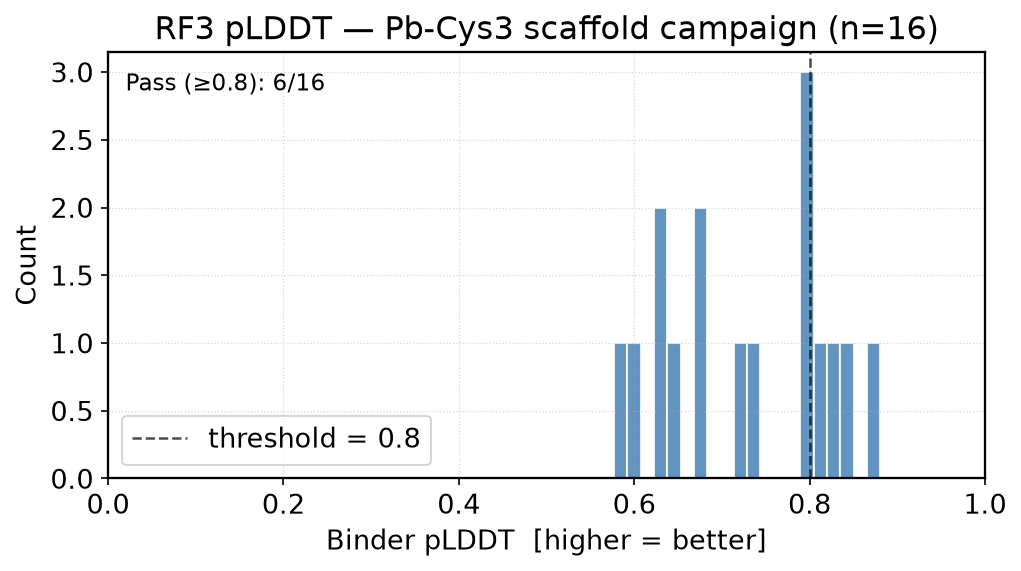

In [41]:
PLDDT_CUT = 0.8   # best_binder_plddt > PLDDT_CUT (0-1)

df = df_rf3
plddt = df['best_binder_plddt'].dropna().to_numpy(float)

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 13,
    "axes.linewidth": 1.1, "figure.dpi": 150,
})
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(plddt, bins=20, color='steelblue', alpha=0.85, edgecolor='white')
ax.axvline(PLDDT_CUT, color='k', lw=1.2, ls='--', alpha=0.7, label=f'threshold = {PLDDT_CUT}')
ax.set_xlabel('Binder pLDDT  [higher = better]')
ax.set_ylabel('Count')
ax.set_title(f'RF3 pLDDT — Pb-Cys3 scaffold campaign (n={len(df)})')
ax.set_xlim(0, 1.0)
ax.legend()
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)
n_pass = int((plddt >= PLDDT_CUT).sum())
ax.text(0.02, 0.95, f'Pass (≥{PLDDT_CUT}): {n_pass}/{len(plddt)}',
        transform=ax.transAxes, va='top', fontsize=11)
fig.tight_layout()
plt.show()

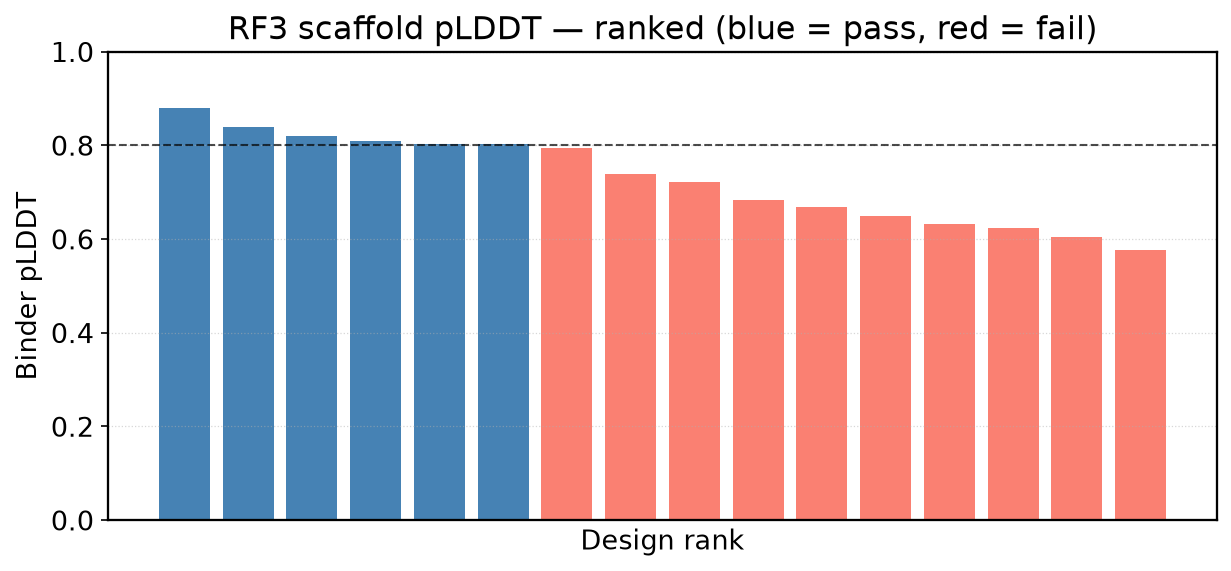

In [42]:
# Per-design pLDDT ranked bar chart — quickly shows which scaffolds fold best.
df_sorted = df_rf3.sort_values('best_binder_plddt', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(max(6, len(df_sorted) * 0.4 + 2), 4))
colors = ['steelblue' if v >= PLDDT_CUT else 'salmon'
          for v in df_sorted['best_binder_plddt']]
ax.bar(range(len(df_sorted)), df_sorted['best_binder_plddt'], color=colors, width=0.8)
ax.axhline(PLDDT_CUT, color='k', lw=1.0, ls='--', alpha=0.7)
ax.set_xlabel('Design rank')
ax.set_ylabel('Binder pLDDT')
ax.set_title('RF3 scaffold pLDDT — ranked (blue = pass, red = fail)')
ax.set_ylim(0, 1.0)
ax.set_xticks([])
ax.grid(True, axis='y', linestyle=':', linewidth=0.6, alpha=0.5)
fig.tight_layout()
plt.show()

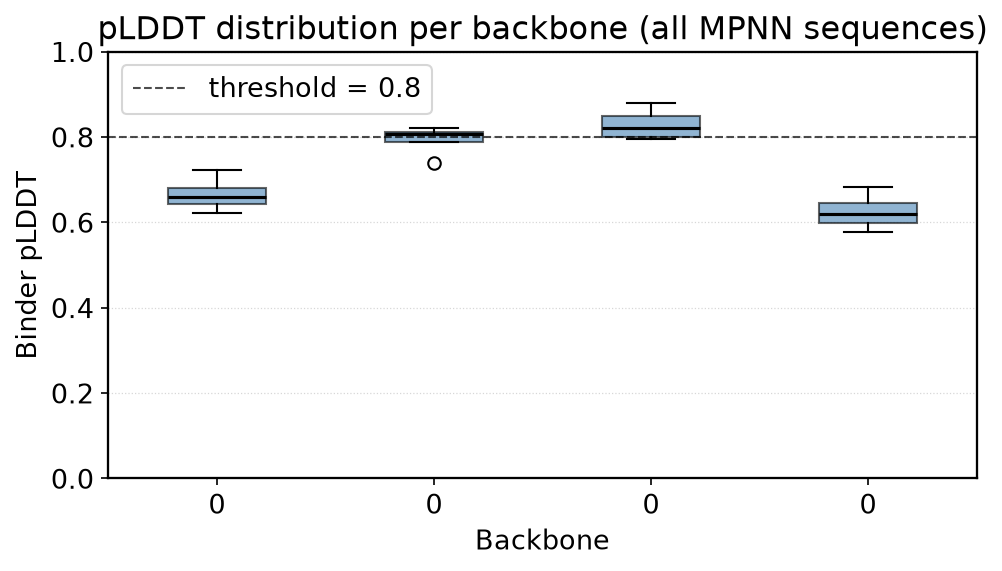

In [43]:
# pLDDT distribution per scaffold (grouped by backbone — each backbone has
# batch_size * number_of_batches MPNN sequences, each folded by RF3).
# A backbone where ALL sequences score above threshold is a strong design.
if 'design_id' in df_rf3.columns:
    import re as _re
    df_rf3['backbone'] = df_rf3['design_id'].str.replace(r'__b\d+_d\d+$', '', regex=True)
    backbone_groups = df_rf3.groupby('backbone')['best_binder_plddt']

    fig, ax = plt.subplots(figsize=(max(6, len(backbone_groups) * 1.2 + 2), 4))
    labels, data = [], []
    for name, grp in backbone_groups:
        labels.append(name.split('_')[-1])
        data.append(grp.dropna().values)

    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5))
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.6)
    ax.axhline(PLDDT_CUT, color='k', lw=1.0, ls='--', alpha=0.7,
               label=f'threshold = {PLDDT_CUT}')
    ax.set_ylabel('Binder pLDDT')
    ax.set_xlabel('Backbone')
    ax.set_ylim(0, 1.0)
    ax.set_title('pLDDT distribution per backbone (all MPNN sequences)')
    ax.legend()
    ax.grid(True, axis='y', linestyle=':', linewidth=0.6, alpha=0.5)
    fig.tight_layout()
    plt.show()
else:
    print("design_id column not found — skip per-backbone breakdown")

### Score RF3 results — with Pb²⁺

Run the same scoring on the with-Pb outputs. A design that scores well here has
a scaffold geometry that RF3 considers compatible with Pb²⁺ coordination.

In [44]:
# Score the with-Pb RF3 outputs.  Re-derive the output directory from WORK so
# this cell works even after a kernel restart.
rf3_out_pb_dir_path = str(WORK / "rf3_out_with_pb")
OUT_CSV_PB = f"{scores_dir}/rf3_gathered_metrics_with_pb.csv"

df_rf3_pb = gather_rf3_metrics(
    parent=rf3_out_pb_dir_path,
    binder=BINDER,
    target_f=TARGET_F,
    target_g=TARGET_G,
    out_csv=OUT_CSV_PB,
)
print(f"{len(df_rf3_pb)} designs scored (with Pb²⁺)")
df_rf3_pb.sort_values("best_binder_plddt", ascending=False).head()

Wrote 16 records → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/scores/rf3_gathered_metrics_with_pb.csv
16 designs scored (with Pb²⁺)


,design_id,score_file,best_binder_plddt,AF_best_min_pae,AF_ipsae_at_best,AG_best_min_pae,AG_ipsae_at_best,best_batch_idx
9,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.838838,NaN,NaN,NaN,NaN,4
8,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.827149,NaN,NaN,NaN,NaN,2
4,rfd3_input_5gpe_pb_motif_r4_1_model_0__b0_d0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.737938,NaN,NaN,NaN,NaN,2
7,rfd3_input_5gpe_pb_motif_r4_1_model_0__b1_d1,/dtu/blackhole/09/214281/lead_sensoring/design...,0.737332,NaN,NaN,NaN,NaN,0
10,rfd3_input_5gpe_pb_motif_r4_2_model_0__b1_d0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.734154,NaN,NaN,NaN,NaN,2


Designs folded in both conditions : 16
  Pass without Pb  (pLDDT ≥ 0.8): 6
  Pass with Pb     (pLDDT ≥ 0.8): 2
  Pass BOTH (candidates):                  2


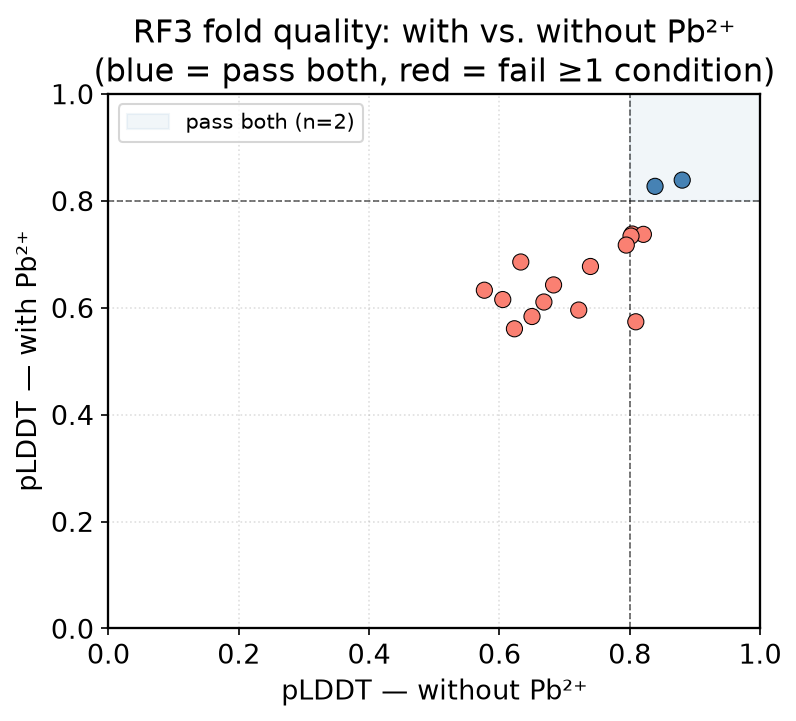

,design_id,plddt_no_pb,batch_no_pb,score_file_no_pb,plddt_with_pb,batch_with_pb,score_file_with_pb
9,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d1,0.880616,4,/dtu/blackhole/09/214281/lead_sensoring/design...,0.838838,4,/dtu/blackhole/09/214281/lead_sensoring/design...
8,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d0,0.838918,4,/dtu/blackhole/09/214281/lead_sensoring/design...,0.827149,2,/dtu/blackhole/09/214281/lead_sensoring/design...
7,rfd3_input_5gpe_pb_motif_r4_1_model_0__b1_d1,0.821024,4,/dtu/blackhole/09/214281/lead_sensoring/design...,0.737332,0,/dtu/blackhole/09/214281/lead_sensoring/design...
5,rfd3_input_5gpe_pb_motif_r4_1_model_0__b0_d1,0.809403,0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.573764,0,/dtu/blackhole/09/214281/lead_sensoring/design...
4,rfd3_input_5gpe_pb_motif_r4_1_model_0__b0_d0,0.803936,4,/dtu/blackhole/09/214281/lead_sensoring/design...,0.737938,2,/dtu/blackhole/09/214281/lead_sensoring/design...
10,rfd3_input_5gpe_pb_motif_r4_2_model_0__b1_d0,0.802028,0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.734154,2,/dtu/blackhole/09/214281/lead_sensoring/design...
11,rfd3_input_5gpe_pb_motif_r4_2_model_0__b1_d1,0.794764,3,/dtu/blackhole/09/214281/lead_sensoring/design...,0.717292,0,/dtu/blackhole/09/214281/lead_sensoring/design...
6,rfd3_input_5gpe_pb_motif_r4_1_model_0__b1_d0,0.739776,0,/dtu/blackhole/09/214281/lead_sensoring/design...,0.677244,2,/dtu/blackhole/09/214281/lead_sensoring/design...
3,rfd3_input_5gpe_pb_motif_r4_0_model_0__b1_d1,0.721814,4,/dtu/blackhole/09/214281/lead_sensoring/design...,0.595724,0,/dtu/blackhole/09/214281/lead_sensoring/design...
13,rfd3_input_5gpe_pb_motif_r4_3_model_0__b0_d1,0.683177,3,/dtu/blackhole/09/214281/lead_sensoring/design...,0.642745,4,/dtu/blackhole/09/214281/lead_sensoring/design...


In [45]:
# Merge without-Pb and with-Pb scores; build pass_both used in the collection cell.
# Both conditions must pass: stable fold without metal + plausible Pb-coordination geometry.
df_merged = (
    df_rf3[["design_id", "best_binder_plddt", "best_batch_idx", "score_file"]]
    .rename(columns={
        "best_binder_plddt": "plddt_no_pb",
        "best_batch_idx":    "batch_no_pb",
        "score_file":        "score_file_no_pb",
    })
    .merge(
        df_rf3_pb[["design_id", "best_binder_plddt", "best_batch_idx", "score_file"]].rename(
            columns={
                "best_binder_plddt": "plddt_with_pb",
                "best_batch_idx":    "batch_with_pb",
                "score_file":        "score_file_with_pb",
            }
        ),
        on="design_id",
        how="inner",
    )
)

n_no   = int((df_merged["plddt_no_pb"]   >= PLDDT_CUT).sum())
n_pb   = int((df_merged["plddt_with_pb"] >= PLDDT_CUT).sum())
pass_both = df_merged[
    (df_merged["plddt_no_pb"]  >= PLDDT_CUT) &
    (df_merged["plddt_with_pb"] >= PLDDT_CUT)
].copy()

print(f"Designs folded in both conditions : {len(df_merged)}")
print(f"  Pass without Pb  (pLDDT ≥ {PLDDT_CUT}): {n_no}")
print(f"  Pass with Pb     (pLDDT ≥ {PLDDT_CUT}): {n_pb}")
print(f"  Pass BOTH (candidates):                  {len(pass_both)}")

col = [
    "steelblue"
    if (r.plddt_no_pb >= PLDDT_CUT and r.plddt_with_pb >= PLDDT_CUT)
    else "salmon"
    for _, r in df_merged.iterrows()
]
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(df_merged["plddt_no_pb"], df_merged["plddt_with_pb"],
           c=col, edgecolors="k", linewidths=0.5, s=60, zorder=3)
ax.axvline(PLDDT_CUT, color="k", ls="--", lw=0.8, alpha=0.6)
ax.axhline(PLDDT_CUT, color="k", ls="--", lw=0.8, alpha=0.6)
ax.fill_between(
    [PLDDT_CUT, 1.0], PLDDT_CUT, 1.0,
    alpha=0.07, color="steelblue", label=f"pass both (n={len(pass_both)})"
)
ax.set_xlabel("pLDDT — without Pb²⁺")
ax.set_ylabel("pLDDT — with Pb²⁺")
ax.set_title("RF3 fold quality: with vs. without Pb²⁺\n(blue = pass both, red = fail ≥1 condition)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

df_merged.sort_values("plddt_no_pb", ascending=False)

## 4. Collect your best binders

Designs passing **pLDDT > 0.8 in BOTH folding conditions** (with and without Pb²⁺)
are copied to `best_binders/` — both the without-Pb and with-Pb RF3 structures. Both conditions matter:

- **Without Pb²⁺** — the scaffold is intrinsically stable and expressible; a protein
  that only folds in the presence of Pb may be difficult to produce in the lab.
- **With Pb²⁺** — the Cys-triad geometry is compatible with Pb coordination as judged
  by RF3's structure model.

**After collecting, verify top candidates in PyMOL or ChimeraX:**
- Cys78, Cys113, Cys122 should cluster within ~5 Å of each other (hemidirected geometry).
- The scaffold core should be compact with no large hydrophobic voids near the Cys triad.
- The C-terminal SpyTag (~19 residues) should be surface-exposed (low B-factor / disordered).

In [46]:
import gzip as _gz

# Select designs that pass pLDDT threshold in BOTH conditions (pass_both from above).
df_best = pass_both.copy()
print(f"{len(df_best)} / {len(df_merged)} designs pass pLDDT ≥ {PLDDT_CUT} "
      f"without AND with Pb²⁺")

best_dir = Path(best_binders_dir)
best_dir.mkdir(parents=True, exist_ok=True)

copied_cif, copied_cif_pb, copied_json, missing = 0, 0, 0, []
for _, row in df_best.iterrows():
    did  = row["design_id"]
    bidx = int(row["batch_no_pb"])
    sf   = Path(row["score_file_no_pb"])

    # without-Pb structure
    cif_src = sf.parent / f"{did}_model_{bidx}.cif.gz"
    dst_cif = best_dir / f"{did}_model_{bidx}.cif"
    if cif_src.exists():
        with _gz.open(cif_src, "rb") as gz_in, open(dst_cif, "wb") as out:
            out.write(gz_in.read())
        copied_cif += 1
    else:
        missing.append(str(cif_src))

    # with-Pb structure
    bidx_pb = int(row["batch_with_pb"])
    sf_pb   = Path(row["score_file_with_pb"])
    cif_pb_src = sf_pb.parent / f"{did}_model_{bidx_pb}.cif.gz"
    dst_cif_pb = best_dir / f"{did}_model_{bidx_pb}_with_pb.cif"
    if cif_pb_src.exists():
        with _gz.open(cif_pb_src, "rb") as gz_in, open(dst_cif_pb, "wb") as out:
            out.write(gz_in.read())
        copied_cif_pb += 1
    else:
        missing.append(str(cif_pb_src))

    json_src = Path(rf3_json_dir) / f"{did}.json"
    dst_json = best_dir / f"{did}.json"
    if json_src.exists():
        shutil.copy2(json_src, dst_json)
        copied_json += 1
    else:
        missing.append(str(json_src))

print(f"Copied {copied_cif} CIF (no-Pb) + {copied_cif_pb} CIF (with-Pb) + {copied_json} JSON → {best_dir}")
if missing:
    print(f"Missing {len(missing)} source file(s):")
    for m in missing[:10]:
        print("  ", m)

best_csv = best_dir / "best_binders_metrics.csv"
df_best.to_csv(best_csv, index=False)
print(f"Metrics → {best_csv}")
df_best[["design_id", "plddt_no_pb", "plddt_with_pb"]]

2 / 16 designs pass pLDDT ≥ 0.8 without AND with Pb²⁺
Copied 2 CIF (no-Pb) + 2 CIF (with-Pb) + 2 JSON → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/best_binders
Metrics → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/best_binders/best_binders_metrics.csv


,design_id,plddt_no_pb,plddt_with_pb
8,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d0,0.838918,0.827149
9,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d1,0.880616,0.838838


## Optional: Tandem-repeat constructs for two Pb-binding sites

The simplest route to a two-site protein is **tandem duplication** of the best
scaffold. No additional RFD3 run is needed:

```
[scaffold] — GSGSGSG — [scaffold] — GSGSGSAHIVMVDAYKPTK
    site 1   7-aa linker   site 2       SpyTag (C-term)
```

Each copy of the scaffold contributes one complete Pb-Cys3 binding site. The resulting
protein (~200–300 aa total, plus SpyTag) has two independent Pb²⁺ coordination sites and
is anchored to the membrane via its single C-terminal SpyTag — exactly the geometry needed
for a high-avidity surface-displayed sensor or affinity column.

**Important:** these sequences are for expression and experimental testing. To validate
computationally, you would need to fold the tandem against two copies of the motif context
as separate RF3 components — a straightforward extension of the RF3 template, not shown here.

Run this cell only after `df_best` is non-empty.

In [47]:
# -- Optional: generate tandem-repeat sequences from best binders ------------------
if "df_best" not in dir() or df_best is None or df_best.empty:
    raise SystemExit("df_best is empty or undefined — run 'Collect your best binders' first.")

TANDEM_LINKER = "GSGSGSG"   # 7 aa; long enough to decouple the two Pb-binding sites

tandem_dir = Path(best_binders_dir) / "tandem_repeats"
tandem_dir.mkdir(parents=True, exist_ok=True)

tandem_records = []

for _, row in df_best.iterrows():
    did      = row["design_id"]
    json_src = Path(rf3_json_dir) / f"{did}.json"
    if not json_src.exists():
        print(f"[SKIP] {did} — RF3 JSON not found")
        continue

    with open(json_src) as f:
        jdata = json.load(f)

    # Recover scaffold-only sequence by stripping the SpyTag appended in cell-21
    full_chain_a = next(
        c["seq"] for c in jdata["components"]
        if isinstance(c, dict) and c.get("chain_id") == "A"
    )
    scaffold_seq = full_chain_a[: len(full_chain_a) - len(SPYTAG)]

    # Build: site1 + GS-linker + site2 + SpyTag
    tandem_seq = scaffold_seq + TANDEM_LINKER + scaffold_seq + SPYTAG

    fasta_out = tandem_dir / f"{did}_tandem.fa"
    with open(fasta_out, "w") as f:
        f.write(f">{did}_tandem | two_Pb_sites | SpyTag_Cterm\n{tandem_seq}\n")

    tandem_records.append({
        "design_id":        did,
        "plddt_no_pb":      row["plddt_no_pb"],
        "plddt_with_pb":    row["plddt_with_pb"],
        "scaffold_len":     len(scaffold_seq),
        "tandem_total_len": len(tandem_seq),
        "fasta":            str(fasta_out),
    })

df_tandem = pd.DataFrame(tandem_records)
print(f"Generated {len(df_tandem)} tandem-repeat FASTA(s) → {tandem_dir}")
if not df_tandem.empty:
    print("\nNext steps:")
    print("  1. Order synthetic genes for the top 3–5 tandem constructs.")
    print("  2. Express in E. coli (His-tag or direct SpyCatcher-resin capture).")
    print("  3. Test Pb²⁺ binding by ITC or fluorescence quenching vs. Zn²⁺, Cd²⁺, Cu²⁺.")
    print("  4. For column: pack SpyCatcher-Sepharose, flow Pb²⁺-spiked buffer, measure ICP-MS.")
df_tandem

Generated 2 tandem-repeat FASTA(s) → /dtu/blackhole/09/214281/lead_sensoring/design/work/exp_01/best_binders/tandem_repeats

Next steps:
  1. Order synthetic genes for the top 3–5 tandem constructs.
  2. Express in E. coli (His-tag or direct SpyCatcher-resin capture).
  3. Test Pb²⁺ binding by ITC or fluorescence quenching vs. Zn²⁺, Cd²⁺, Cu²⁺.
  4. For column: pack SpyCatcher-Sepharose, flow Pb²⁺-spiked buffer, measure ICP-MS.


,design_id,plddt_no_pb,plddt_with_pb,scaffold_len,tandem_total_len,fasta
0,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d0,0.838918,0.827149,93,212,/dtu/blackhole/09/214281/lead_sensoring/design...
1,rfd3_input_5gpe_pb_motif_r4_2_model_0__b0_d1,0.880616,0.838838,93,212,/dtu/blackhole/09/214281/lead_sensoring/design...
